In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

2025-05-15 21:44:12.165356: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747345452.378245      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747345452.440806      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
import os
print(os.listdir("/kaggle/input"))

In [3]:
# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
N_SPLITS = 10
EPOCHS = 20
NUM_CLASSES = 3

# Dataset Path
DATA_PATH = '/kaggle/input/normal-pneumo-lungop/Normal Pneumo LungOp'

# Load dataset (for file paths and labels only)
raw_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    labels='inferred',
    label_mode='categorical', 
    color_mode='rgb',
    batch_size= BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
    seed=SEED
)

# Extract file paths and labels
file_paths = raw_dataset.file_paths
labels = np.concatenate([y.numpy() for _, y in raw_dataset], axis=0)
labels = np.argmax(labels, axis=1)  # Convert one-hot to categorical

Found 20477 files belonging to 3 classes.


I0000 00:00:1747346053.621052      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
raw_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size= BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
    seed=SEED
)

class_names = raw_dataset.class_names
print(class_names)  # ✅ Use this as your official class_names


Found 20477 files belonging to 3 classes.
['Lung_Opacity', 'Normal', 'Pneumonia']


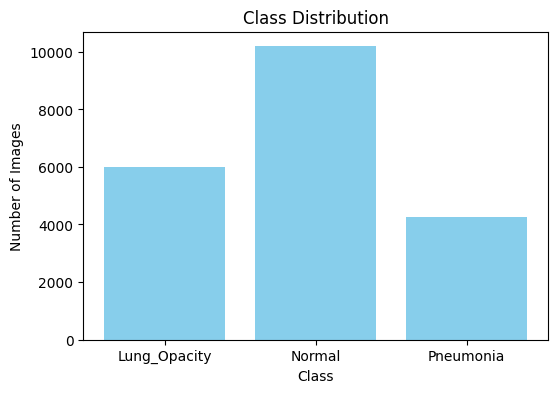

In [6]:
# visualize dataset and prove inbalance
class_names = sorted(os.listdir(DATA_PATH))
class_counts = np.bincount(labels)
plt.figure(figsize=(6, 4))
plt.bar(class_names, class_counts, color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

In [7]:
# First split into train/test (80/20)
train_paths_full, test_paths, train_labels_full, test_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=SEED, stratify=labels
)

# Then split train into train/val (80/20 of 80%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_full, train_labels_full, test_size=0.2, random_state=SEED, stratify=train_labels_full
)

# Function to load dataset with preprocessing options
def load_dataset(paths, labels, augment=False, normalize=True):
    def process(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        
        if normalize:
            img = img / 255.0  # Normalize to [0,1]
            
        return img, tf.one_hot(label, depth=NUM_CLASSES)
    
    def augment_image(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.04)
        img = tf.image.random_contrast(img, lower=0.95, upper=1.05)
        return img, label
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process)
    
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [8]:
def build_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),

        tf.keras.layers.Conv2D(32, (3, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, (3, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),


        tf.keras.layers.Conv2D(64, (3, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, (3, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),


        tf.keras.layers.Conv2D(128, (3, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, (3, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),


        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    def focal_loss(gamma=2.0, alpha=0.25):
        def loss(y_true, y_pred):
            epsilon = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
            cross_entropy = -y_true * tf.math.log(y_pred)
            weight = alpha * tf.math.pow(1 - y_pred, gamma)
            return tf.reduce_sum(weight * cross_entropy, axis=1)
        return loss
    model.compile(optimizer=optimizer, loss=focal_loss(gamma=2., alpha=0.25), metrics=['accuracy'])
    return model


In [9]:
class_weights = {
    0: 1.0,   # Normal (10k)
    1: 2.5,   # Pneumonia (4k)
    2: 1.7    # Lung Opacity (6k)
}

## less aggressive augmentation + NORMALIZATION + BASIC CNN

Epoch 1/20


I0000 00:00:1747348344.475673      80 service.cc:148] XLA service 0x7db214018020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747348344.476291      80 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1747348345.222742      80 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/410 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.2579 - loss: 0.5813 

I0000 00:00:1747348351.381078      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


410/410 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.6100 - loss: 0.3642 - val_accuracy: 0.5963 - val_loss: 0.2231 - learning_rate: 1.0000e-05
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.7941 - loss: 0.2263 - val_accuracy: 0.8676 - val_loss: 0.1539 - learning_rate: 3.0000e-05
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.8449 - loss: 0.1818 - val_accuracy: 0.7644 - val_loss: 0.1704 - learning_rate: 5.0000e-05
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.8648 - loss: 0.1625 - val_accuracy: 0.8279 - val_loss: 0.1481 - learning_rate: 7.0000e-05
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8763 - loss: 0.1541 - val_accuracy: 0.8108 - val_loss: 0.1542 - learning_rate: 7.0000e-05
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8809 - loss: 0.1489 - val_accuracy: 0.8837 - val_loss: 0.1358 - learning_rate: 7.0000e-05
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accurac

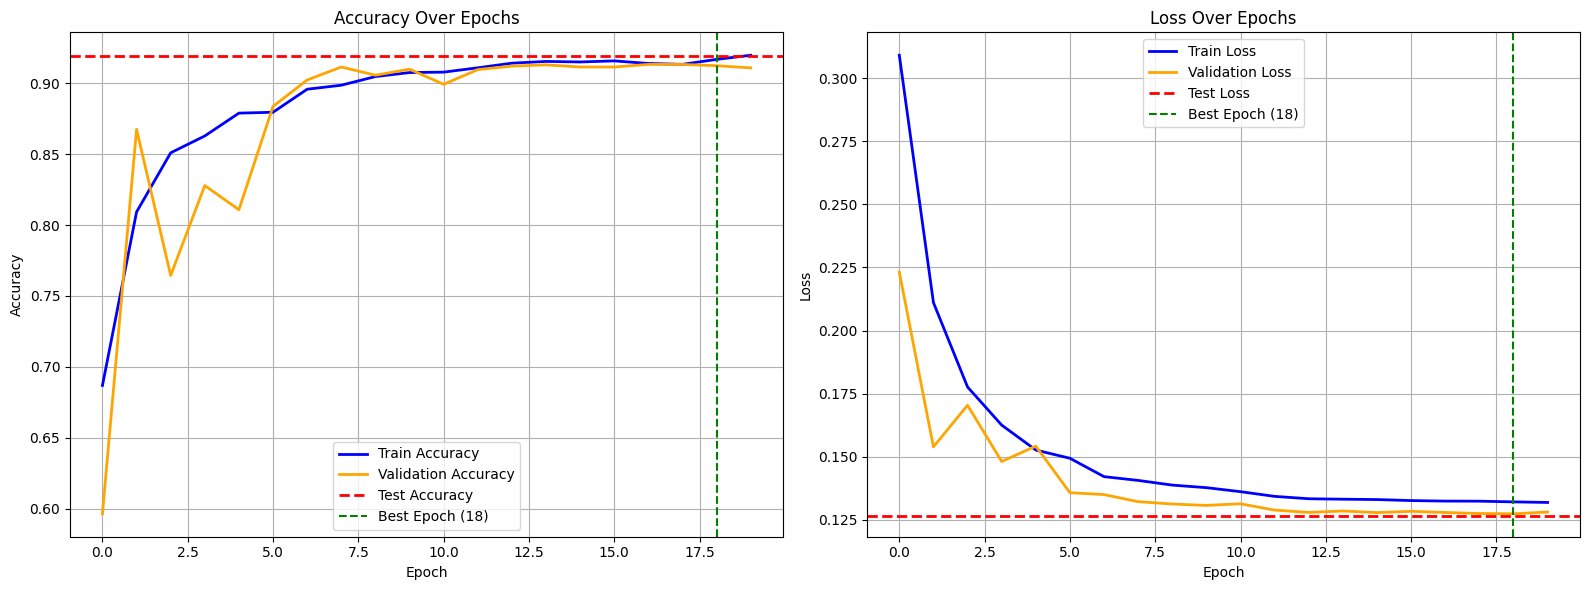

In [10]:
# Combined preprocessing configuration
combined_config = {
    "augment": True,
    "normalize": True,
    "name": "Full Preprocessing (Norm+Aug)"
}

# Load train dataset
train_ds = load_dataset(
    train_paths, train_labels, 
    augment=combined_config['augment'], 
    normalize=combined_config['normalize']
)

# Load validation dataset
val_ds = load_dataset(
    val_paths, val_labels, 
    augment=False,  # No augmentation for validation!
    normalize=combined_config['normalize']
)

# Load test dataset
test_ds = load_dataset(
    test_paths, test_labels, 
    augment=False, 
    normalize=combined_config['normalize']
)

# Train model
model = build_cnn()
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
# Example: Custom learning rate scheduler
def lr_schedule(epoch):
    if epoch < 3:
        return 1e-5 + epoch * (7e-5 - 1e-5) / 3  # warm-up from 1e-5 to 7e-5
    elif epoch < 6:
        return 7e-5  # Slightly lower peak LR
    elif epoch < 12:
        return 1e-5  # Gradual decay
    else:
        return 1e-6  # Further decay

# Create the LearningRateScheduler callback
lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[early_stop,reduce_lr, lr_callback],
    class_weight=class_weights
)

loss, acc = model.evaluate(test_ds, verbose=0)

# Extract training history
full_history = history.history
full_test_metrics = {'loss': loss, 'accuracy': acc}

# Create comprehensive visualization
plt.figure(figsize=(16, 6))

# Identify epoch with best val_loss
best_epoch = np.argmin(full_history['val_loss'])

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(full_history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(full_history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.axhline(y=full_test_metrics['accuracy'], color='red', linestyle='--', linewidth=2, label='Test Accuracy')
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(full_history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(full_history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.axhline(y=full_test_metrics['loss'], color='red', linestyle='--', linewidth=2, label='Test Loss')
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


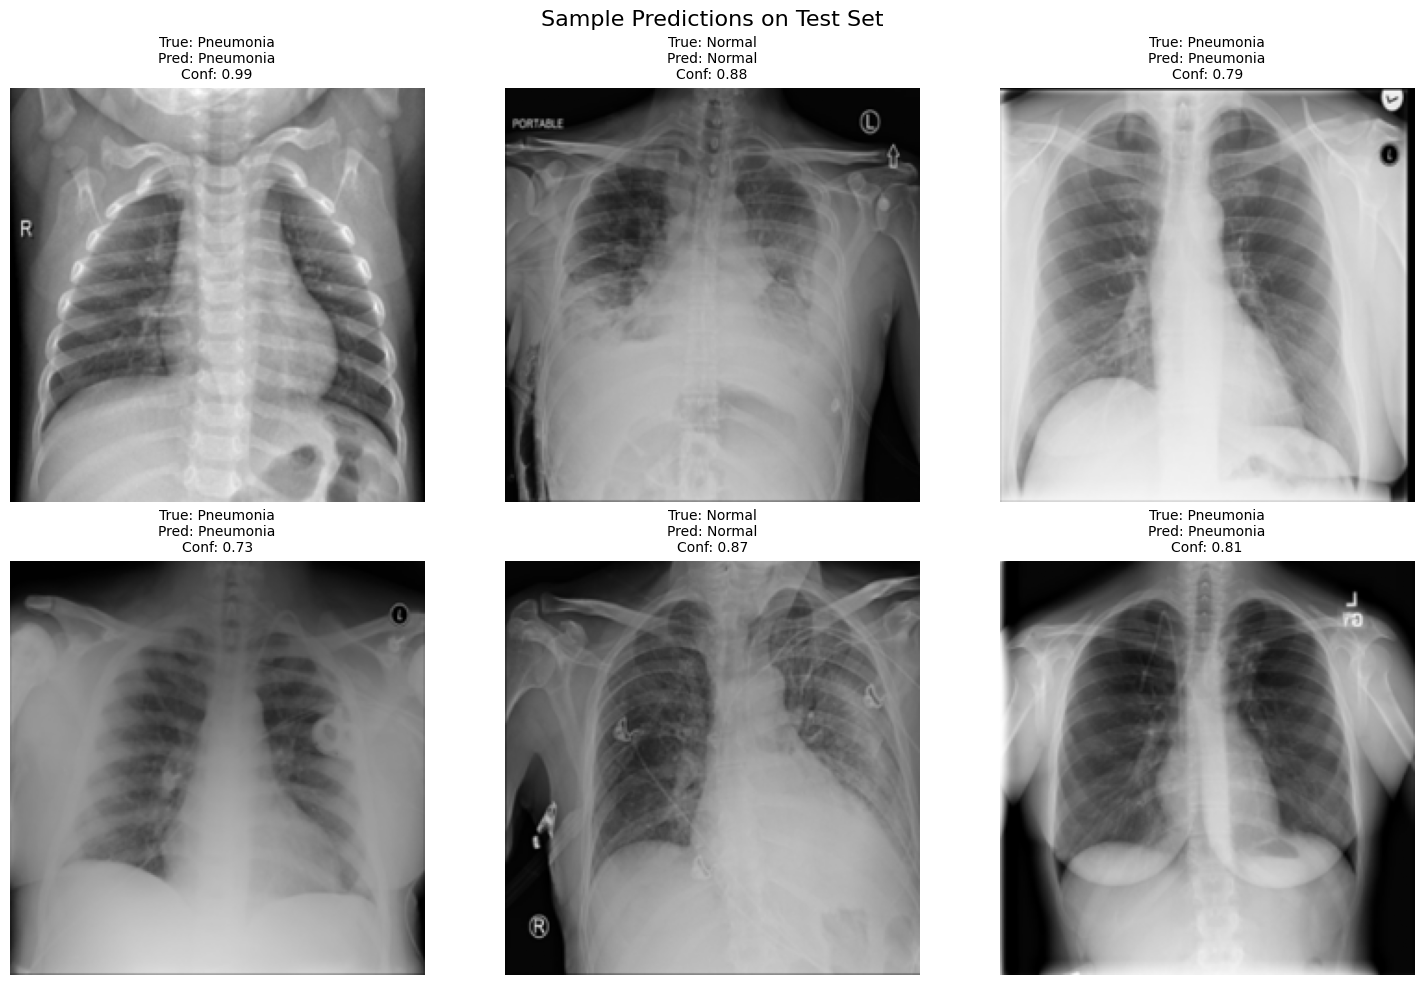

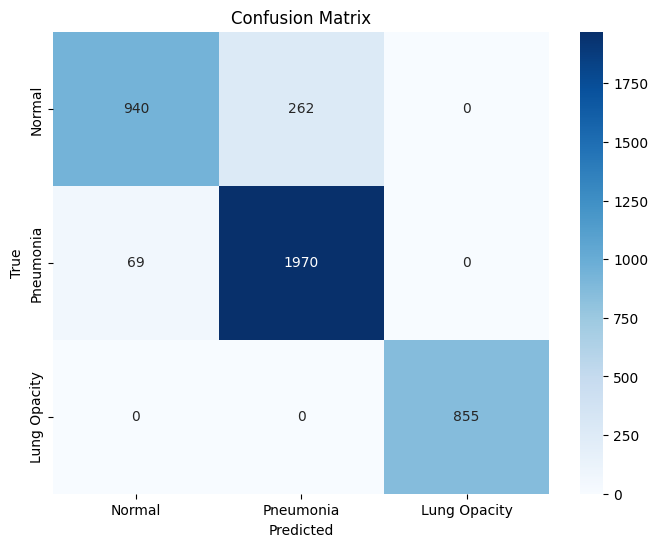


          Test Set Evaluation           
Accuracy: 0.9192
Loss: 0.1264

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.78      0.85      1202
   Pneumonia       0.88      0.97      0.92      2039
Lung Opacity       1.00      1.00      1.00       855

    accuracy                           0.92      4096
   macro avg       0.94      0.92      0.92      4096
weighted avg       0.92      0.92      0.92      4096



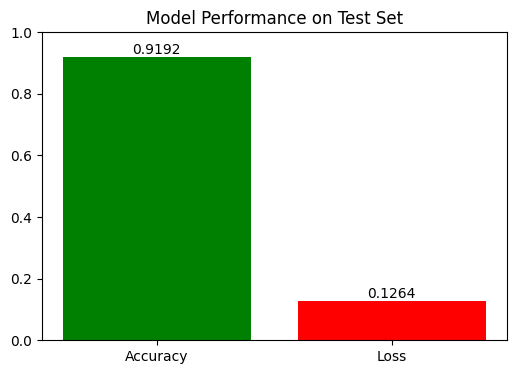

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

# Part 1: Random sample visualization
plt.figure(figsize=(15, 10))

# Get 6 random indices from test set
sample_indices = random.sample(range(len(test_paths)), 6)

for i, idx in enumerate(sample_indices):
    # Load and process the image
    img = tf.io.read_file(test_paths[idx])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    
    # Get true and predicted labels
    true_label = test_labels[idx]
    pred_prob = model.predict(tf.expand_dims(img, axis=0))
    pred_label = np.argmax(pred_prob)
    
    # Map numeric labels to class names
    class_names = ['Normal', 'Pneumonia', 'Lung Opacity']
    true_class = class_names[true_label]
    pred_class = class_names[pred_label]
    confidence = np.max(pred_prob)
    
    # Plot
    plt.subplot(2, 3, i+1)
    plt.imshow(img.numpy())
    plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}", fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Predictions on Test Set', fontsize=16)
plt.tight_layout()
plt.show()

# Part 2: Confusion Matrix
# Get all predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Part 3: Evaluation Metrics
# Calculate metrics
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
classification_rep = classification_report(y_true, y_pred, target_names=class_names)

# Display metrics
print(f"\n{'='*40}")
print(f"{'Test Set Evaluation':^40}")
print(f"{'='*40}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Loss: {test_loss:.4f}\n")
print("Classification Report:")
print(classification_rep)
print(f"{'='*40}")

# Additional metrics visualization
metrics = ['Accuracy', 'Loss']
values = [test_acc, test_loss]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values, color=['green', 'red'])
plt.title('Model Performance on Test Set')
plt.ylim(0, 1 if max(values) <= 1 else None)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.show()

In [1]:
model.save("my_model.keras")

NameError: name 'model' is not defined

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 222, 222, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 107, 107, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 107, 107, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 107, 107, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 51, 51, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 49, 49, 128)         │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 49, 49, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 49, 49, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 22, 22, 32)          │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 15488)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,982,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 6,314,731 (24.09 MB)

 Trainable params: 2,104,675 (8.03 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 4,209,352 (16.06 MB)